<a href="https://colab.research.google.com/github/NelvaAdalit/-INTELIGENCIA-ARTIFICIAL-I-/blob/main/LAB2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 2: Regresión Logística (Clasificación Binaria)
**Estudiante:** Nelva Adalit Mora Barrionuevo  
**Carrera:** Ingeniería de Sistemas  
**Dataset:** Network Intrusion dataset (CIC-IDS-2017)  

### Descripción del Problema
El presente laboratorio implementa un modelo de Regresión Logística para la detección de intrusiones en redes informáticas. Se utiliza un dataset masivo con características de tráfico de red ($n=79$ variables) para clasificar si una sesión corresponde a tráfico normal (`0`) o a un ataque de denegación de servicio (`1`). El volumen de datos procesado supera los 220,000 registros ($m > 30000$).

In [ ]:
# Importación de librerías
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from google.colab import drive

In [ ]:
# 1. CARGA Y LIMPIEZA DE DATOS
# ==========================================
drive.mount('/content/drive')

ruta_archivo = '/content/drive/MyDrive/SIS420IA/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
print("Cargando el dataset... esto puede tardar unos segundos.")
df = pd.read_csv(ruta_archivo, low_memory=False)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.columns = df.columns.str.strip()
df['Label'] = df['Label'].map({'BENIGN': 0, 'DDoS': 1})

print("\n--- VISTA PREVIA DEL DATASET LIMPIO ---")
display(df.head())

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
print(f"\nDataset cargado. Filas (m): {X.shape[0]}, Columnas (n): {X.shape[1]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando el dataset... esto puede tardar unos segundos.

--- VISTA PREVIA DEL DATASET LIMPIO ---


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0



Dataset cargado. Filas (m): 225711, Columnas (n): 78


In [ ]:
# 2. NORMALIZACIÓN
# ==========================================
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

print("\nNormalizando características...")
X_ready, mu, sigma = featureNormalize(X)

m = X_ready.shape[0]
X_ready = np.concatenate([np.ones((m, 1)), X_ready], axis=1)
print(f"Matriz lista con columna de unos. Nueva forma de X: {X_ready.shape}")


Normalizando características...
Matriz lista con columna de unos. Nueva forma de X: (225711, 79)


In [ ]:
# 3. FUNCIONES MATEMÁTICAS (Del Ingeniero)
# ==========================================
def sigmoid(z):
    z = np.array(z)
    return 1 / (1 + np.exp(-z))

def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(np.dot(X, theta))
    epsilon = 1e-15
    J = (1 / m) * np.sum(-y * np.log(h + epsilon) - (1 - y) * np.log(1 - h + epsilon))
    return J

def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        h = sigmoid(np.dot(X, theta))
        theta = theta - (alpha / m) * np.dot(X.T, (h - y))
        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

def costFunction(theta, X, y):
    m = y.size
    h = sigmoid(np.dot(X, theta))
    epsilon = 1e-15
    J = (1 / m) * np.sum(-y * np.log(h + epsilon) - (1 - y) * np.log(1 - h + epsilon))
    grad = (1 / m) * np.dot(X.T, (h - y))
    return J, grad

def predict(theta, X):
    prob = sigmoid(np.dot(X, theta))
    return (prob >= 0.5).astype(int)

In [ ]:
# ==========================================
# 4. ENTRENAMIENTO (Manual y Scipy)
# ==========================================
print("\nCalculando Descenso por Gradiente para la gráfica...")
alpha = 0.1
num_iters = 100
theta_inicial_gd = np.zeros(X_ready.shape[1])
theta_gd, historial_J = descensoGradiente(theta_inicial_gd, X_ready, y, alpha, num_iters)

print("\nOptimizando Thetas finales con Scipy (Método TNC)...")
initial_theta = np.zeros(X_ready.shape[1])
options = {'maxiter': 1000}
res = optimize.minimize(costFunction, initial_theta, (X_ready, y), jac=True, method='TNC', options=options)
theta_optimizado = res.x
print(f"¡Optimización exitosa! Costo final: {res.fun:.4f}")


Calculando Descenso por Gradiente para la gráfica...

Optimizando Thetas finales con Scipy (Método TNC)...


/tmp/ipykernel_1878/1662871380.py:13: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction, initial_theta, (X_ready, y), jac=True, method='TNC', options=options)
/tmp/ipykernel_1878/3111839223.py:5: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


¡Optimización exitosa! Costo final: 0.0034


In [ ]:
# 5. EVALUACIÓN Y 100 PREDICCIONES
# ==========================================
p_total = predict(theta_optimizado, X_ready)
precision_entrenamiento = np.mean(p_total == y) * 100
print(f"\nPrecisión global del modelo: {precision_entrenamiento:.2f} %")

print("\n" + "=" * 80)
print("EVALUACIÓN DE 100 CASOS AL AZAR")
print("=" * 80)

indices_azar = np.random.choice(m, 100, replace=False)
X_prueba = X_ready[indices_azar]
y_real = y[indices_azar]
probabilidades = sigmoid(np.dot(X_prueba, theta_optimizado))
predicciones = predict(theta_optimizado, X_prueba)

aciertos = 0
print(f"{'Nro':<5} | {'Probabilidad':<15} | {'Predicción IA':<18} | {'Realidad':<18} | {'Estado'}")
print("-" * 85)
for i in range(100):
    if predicciones[i] == y_real[i]:
        estado = "✅ CORRECTO"
        aciertos += 1
    else:
        estado = "❌ ERROR"
    texto_pred = "DDoS (Ataque)" if predicciones[i] == 1 else "BENIGN (Normal)"
    texto_real = "DDoS (Ataque)" if y_real[i] == 1 else "BENIGN (Normal)"
    print(f"{i+1:<5} | {probabilidades[i]:<15.4f} | {texto_pred:<18} | {texto_real:<18} | {estado}")

print("-" * 85)
print(f"Efectividad en la prueba de 100: {aciertos}%")


Precisión global del modelo: 99.92 %

EVALUACIÓN DE 100 CASOS AL AZAR
Nro   | Probabilidad    | Predicción IA      | Realidad           | Estado
-------------------------------------------------------------------------------------
1     | 1.0000          | DDoS (Ataque)      | DDoS (Ataque)      | ✅ CORRECTO
2     | 0.0000          | BENIGN (Normal)    | BENIGN (Normal)    | ✅ CORRECTO
3     | 1.0000          | DDoS (Ataque)      | DDoS (Ataque)      | ✅ CORRECTO
4     | 1.0000          | DDoS (Ataque)      | DDoS (Ataque)      | ✅ CORRECTO
5     | 1.0000          | DDoS (Ataque)      | DDoS (Ataque)      | ✅ CORRECTO
6     | 1.0000          | DDoS (Ataque)      | DDoS (Ataque)      | ✅ CORRECTO
7     | 1.0000          | DDoS (Ataque)      | DDoS (Ataque)      | ✅ CORRECTO
8     | 0.0000          | BENIGN (Normal)    | BENIGN (Normal)    | ✅ CORRECTO
9     | 1.0000          | DDoS (Ataque)      | DDoS (Ataque)      | ✅ CORRECTO
10    | 1.0000          | DDoS (Ataque)      | DDoS (Ataq

/tmp/ipykernel_1878/3111839223.py:5: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


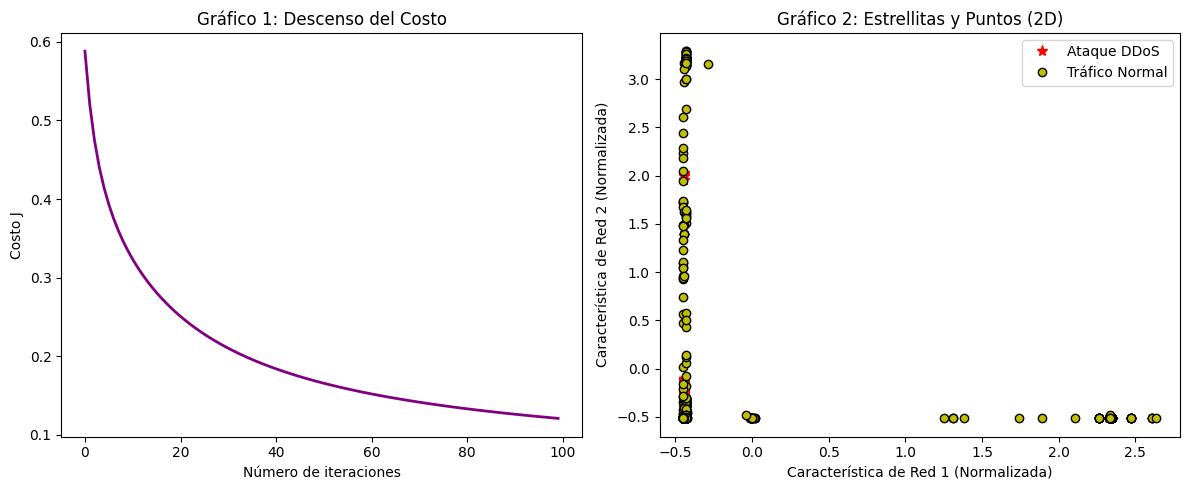

In [ ]:
# 6. GRÁFICOS FINALES (Lado a lado)
# ==========================================
plt.figure(figsize=(12, 5))

# Gráfico 1: Descenso del Costo
plt.subplot(1, 2, 1)
plt.plot(np.arange(len(historial_J)), historial_J, lw=2, color='purple')
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Gráfico 1: Descenso del Costo')

# Gráfico 2: Estrellitas (Clasificación 2D)
plt.subplot(1, 2, 2)
ataques = (y == 1)
normal = (y == 0)
plt.plot(X_ready[ataques][:1000, 1], X_ready[ataques][:1000, 2], 'r*', lw=2, ms=8, label='Ataque DDoS')
plt.plot(X_ready[normal][:1000, 1], X_ready[normal][:1000, 2], 'bo', mfc='y', ms=6, mec='k', mew=1, label='Tráfico Normal')
plt.xlabel('Característica de Red 1 (Normalizada)')
plt.ylabel('Característica de Red 2 (Normalizada)')
plt.title('Gráfico 2: Estrellitas y Puntos (2D)')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 7. VENTANITA INTERACTIVA DE PREDICCIÓN
# ==========================================
import ipywidgets as widgets
from IPython.display import display

print("=" * 60)
print(" 💻 SISTEMA DE DETECCIÓN DE INTRUSOS (DDoS) - PRUEBA EN VIVO")
print("=" * 60)

# Buscamos un ejemplo real de ataque (y == 1) en los datos crudos originales (X)
indice_ejemplo = np.where(y == 1)[0][0]
ejemplo_crudo = X[indice_ejemplo]

# Lo convertimos a texto separado por comas para ponerlo en la ventanita
texto_ejemplo = ", ".join(map(str, ejemplo_crudo))

# 1. Creamos la ventanita de texto
text_area = widgets.Textarea(
    value=texto_ejemplo,
    placeholder='Pega aquí los 78 valores de red separados por comas...',
    description='Datos (78):',
    layout=widgets.Layout(width='90%', height='80px')
)

# 2. Creamos el botón
boton = widgets.Button(
    description="🔍 Analizar Tráfico",
    button_style='success',
    tooltip='Hacer predicción con el modelo',
    icon='search'
)

# 3. Pantalla de salida
salida = widgets.Output()

# 4. La función que se ejecuta al apretar el botón
def al_presionar_boton(b):
    with salida:
        salida.clear_output()
        try:
            # Leemos los datos de la ventanita
            valores_ingresados = np.array([float(x.strip()) for x in text_area.value.split(',')])

            # Verificamos que no falten columnas
            if len(valores_ingresados) != 78:
                print(f"⚠️ ERROR: Ingresaste {len(valores_ingresados)} valores, pero el modelo necesita exactamente 78.")
                return

            # PASO CLAVE: Normalizamos el nuevo dato con el mu y sigma de nuestro entrenamiento
            valores_norm = (valores_ingresados - mu) / sigma

            # Agregamos el "1" al principio para la matriz de thetas
            valores_ready = np.insert(valores_norm, 0, 1)

            # Hacemos la predicción con nuestro theta optimizado
            prob = sigmoid(np.dot(valores_ready, theta_optimizado))
            prediccion = 1 if prob >= 0.5 else 0

            # Imprimimos el resultado con estilo
            print("\n" + "." * 50)
            if prediccion == 1:
                print(f"🚨 ALERTA ROJA: ¡Ataque DDoS Detectado!")
                print(f"   Nivel de certeza de la IA: {prob*100:.2f}%")
            else:
                print(f"✅ TRÁFICO NORMAL: Conexión segura.")
                print(f"   Probabilidad de amenaza: {prob*100:.2f}%")
            print("." * 50)

        except Exception as e:
            print(f"⚠️ Error de lectura. Asegúrate de ingresar solo números separados por comas.")

# Conectamos el botón con la función y dibujamos la ventanita
boton.on_click(al_presionar_boton)
display(text_area, boton, salida)

 💻 SISTEMA DE DETECCIÓN DE INTRUSOS (DDoS) - PRUEBA EN VIVO


Textarea(value='80.0, 1293792.0, 3.0, 7.0, 26.0, 11607.0, 20.0, 0.0, 8.666666667, 10.26320288, 5840.0, 0.0, 16…

Button(button_style='success', description='🔍 Analizar Tráfico', icon='search', style=ButtonStyle(), tooltip='…

Output()